# Boston Regression Project

The objective of this project is to estimate regional median home values (MEDV) using local housing features.

<img src='https://www.rickberk.com/images/xl/Autumn-Twilight-Boston.jpg' width='750'> 

In [1]:
# Libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge,Lasso,ElasticNet
import numpy as np


import warnings
warnings.filterwarnings('ignore')

### EDA

In [17]:
df=pd.read_csv('boston.csv')

In [18]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [19]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [20]:
df.shape

(506, 14)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [22]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [23]:
df['CRIM'].value_counts

<bound method IndexOpsMixin.value_counts of 0      0.00632
1      0.02731
2      0.02729
3      0.03237
4      0.06905
        ...   
501    0.06263
502    0.04527
503    0.06076
504    0.10959
505    0.04741
Name: CRIM, Length: 506, dtype: float64>

In [24]:
df['TAX'].value_counts

<bound method IndexOpsMixin.value_counts of 0      296.0
1      242.0
2      242.0
3      222.0
4      222.0
       ...  
501    273.0
502    273.0
503    273.0
504    273.0
505    273.0
Name: TAX, Length: 506, dtype: float64>

In [25]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [26]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


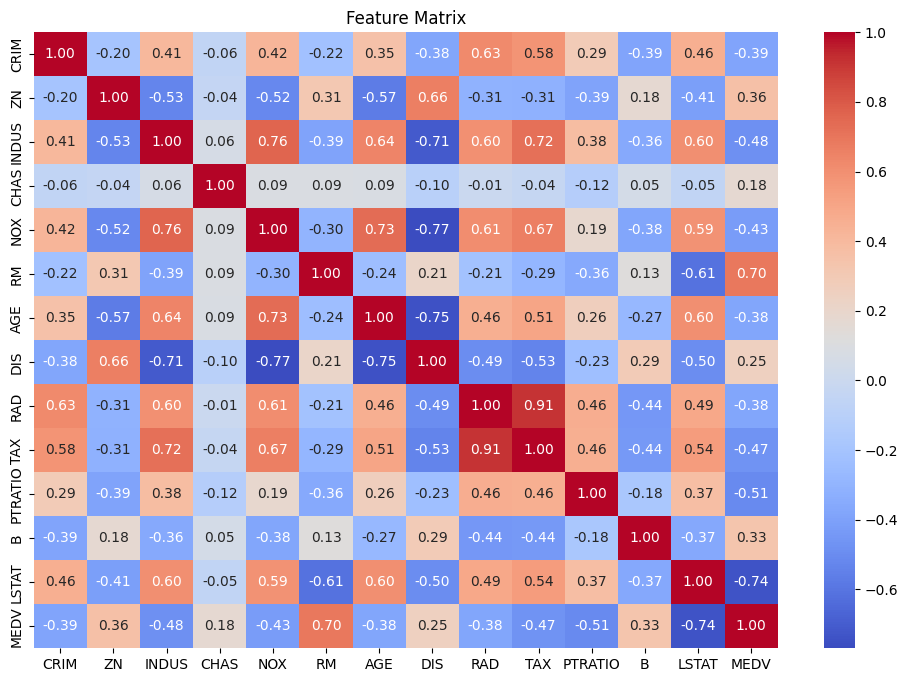

In [27]:
# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')      
plt.title("Feature Matrix")      
plt.show()

In [28]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

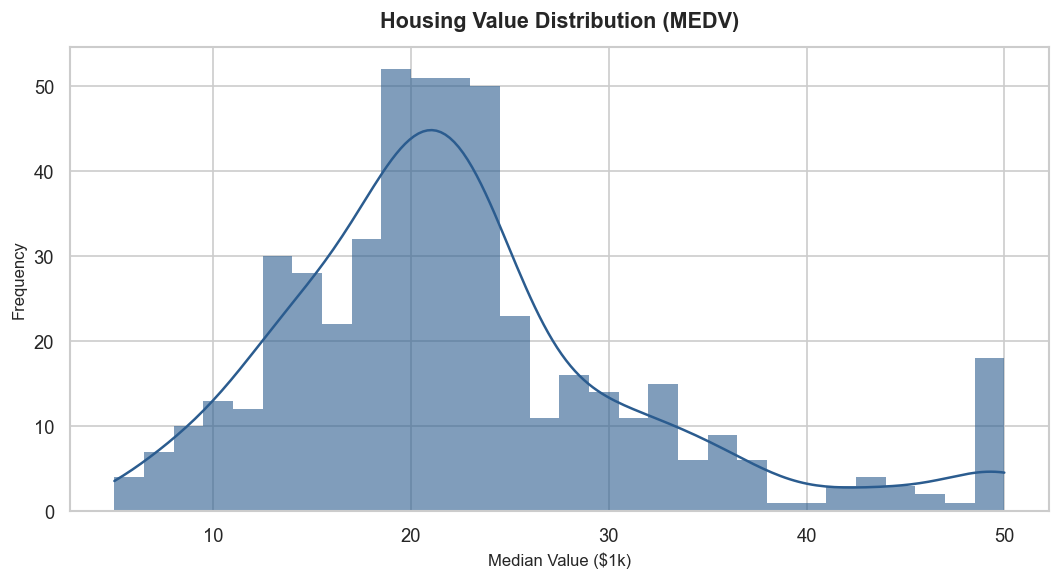

In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5), dpi=120)

# Distribution plot
sns.histplot(df["MEDV"], kde=True, color="#2b5c8f", bins=30, edgecolor="none", alpha=0.6)

# Labels & Annotations
plt.title("Housing Value Distribution (MEDV)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Median Value ($1k)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)

plt.tight_layout()
plt.show()

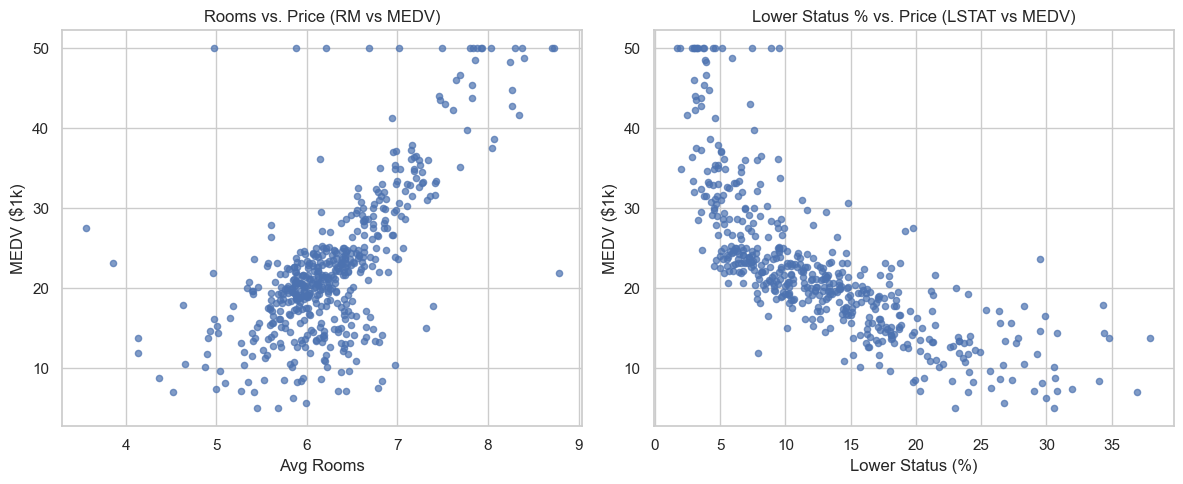

In [31]:
# Plot RM vs MEDV and LSTAT vs MEDV using Pandas built-in plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.plot.scatter(x='RM', y='MEDV', ax=axes[0], title='Rooms vs. Price (RM vs MEDV)', xlabel='Avg Rooms', ylabel='MEDV ($1k)', alpha=0.7)
df.plot.scatter(x='LSTAT', y='MEDV', ax=axes[1], title='Lower Status % vs. Price (LSTAT vs MEDV)', xlabel='Lower Status (%)', ylabel='MEDV ($1k)', alpha=0.7)

plt.tight_layout()
plt.show()

In [32]:
abs(df.corr()["MEDV"].sort_values(ascending=False))

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE        0.376955
RAD        0.381626
CRIM       0.388305
NOX        0.427321
TAX        0.468536
INDUS      0.483725
PTRATIO    0.507787
LSTAT      0.737663
Name: MEDV, dtype: float64

In [33]:
outliers = df.quantile(.97) # dealing with the outliers seen in the boxplots above
df = df[(df['CRIM']<outliers['CRIM'])]
df = df[(df['ZN']<outliers['ZN'])]
df = df[(df['RM']<outliers['RM'])]
df = df[(df['DIS']<outliers['DIS'])]
df = df[(df['PTRATIO']<outliers['PTRATIO'])]
df = df[(df['B']<outliers['B'])]
df = df[(df['LSTAT']<outliers['LSTAT'])]

### Modeling

In [34]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge,Lasso,ElasticNet
import numpy as np

In [35]:
x = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [37]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [38]:
lr=LinearRegression()

In [39]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
predict = lr.predict(x_test)

In [41]:
r2_score(y_test,predict)

0.7501729765601622

In [43]:
mean_squared_error(y_test,predict)**.5

3.8274917967123487

In [60]:
# Function to call all Regression Algorithms
def algo_test(x, y):
    # importing Regression libraries
    from sklearn.linear_model import LinearRegression
    from sklearn.linear_model import Ridge, Lasso
    from sklearn.linear_model import ElasticNet
    from sklearn.tree import ExtraTreeRegressor
    from sklearn.ensemble import GradientBoostingRegressor
    from sklearn.neighbors import KNeighborsRegressor
    from xgboost import XGBRegressor

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

    # split the data in Train and Test 
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    ExTree = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    KN = KNeighborsRegressor()
    XGBC = XGBRegressor()

    algos = [L, R, Lass, E, ExTree, GBR, KN, XGBC]
    algo_names = [
        'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet',
        'ExtraTreeRegressor', 'GradientBoostingRegressor',
        'KNeighborsRegressor', 'XGBRegressor'
    ]
    r_squared = []
    rmse = []
    mae = []

    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)  # create df with results

    for item in algos:  # fit and predict model with all algos and append the results in their lists
        item.fit(x_train, y_train)
        preds = item.predict(x_test)
        r_squared.append(r2_score(y_test, preds))
        rmse.append((mean_squared_error(y_test, preds)) ** .5)
        mae.append(mean_absolute_error(y_test, preds))

    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    return result.sort_values('R_Squared', ascending=False)

In [61]:
algo_test(x,y)

,R_Squared,RMSE,MAE
GradientBoostingRegressor,0.921811,2.141255,1.735261
XGBRegressor,0.874411,2.713755,2.029624
Ridge,0.762796,3.729542,2.730716
LinearRegression,0.750173,3.827492,2.886529
ElasticNet,0.746144,3.858229,2.875123
Lasso,0.734120,3.948547,2.960274
ExtraTreeRegressor,0.583233,4.943574,3.318462
KNeighborsRegressor,0.436140,5.750164,4.068923


In [62]:
from yellowbrick.regressor import ResidualsPlot

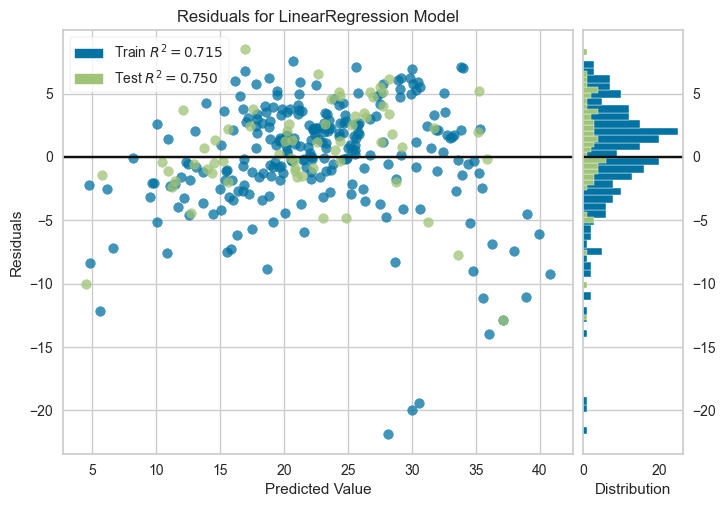

In [63]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

Among all tested models, Gradient Boosting Regressor achieved the best overall performance with the highest $R^2$ score of 0.92 and the lowest $RMSE$ of 2.14.